# Exact Cover: Comparing Grover and XY Mixers

This notebook loads a previously computed QAOA result for an exact cover problem
with **known Hamming weight** (solved with a Grover mixer), reruns the same
problem using **both** the Grover mixer and the XY mixer from scratch, and
compares all three sets of results.

Comparing the loaded Grover result against a freshly computed Grover result
serves as a sanity check that the IO roundtrip and problem reconstruction
produce consistent outcomes.


In [1]:
from qaoa import QAOA, problems, mixers, initialstates
from qaoa.util import qaoaIO as qio
from qaoa.util.plotroutines import *

import numpy as np
from matplotlib import pyplot as plt
import os

## Load previous Grover-mixer result

In [2]:
grover_result = qio.QAOAResult.load(
    os.path.join("data", "exact_cover_path_problem_example.json")
)

problem_data = grover_result.problem
print(f"Problem type:    {problem_data.problem_type}")
print(f"N qubits:        {grover_result.qaoa_params.N_qubits}")
print(f"Hamming weight:  {problem_data.hamming_weight}")
print(f"Mixer used:      {grover_result.qaoa_params.mixer_method}")
print(f"Depths computed: {sorted(grover_result.qaoa_params.depths.keys())}")
print(f"Known solution:  {problem_data.solution}")

Problem type:    ExactCover
N qubits:        8
Hamming weight:  2
Mixer used:      MixerMethod.GROVER
Depths computed: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Known solution:  [1. 0. 0. 1. 0. 0. 0. 0.]


## Reconstruct the problem and find the optimal solution via brute force

In [3]:
ec_problem = grover_result.get_problem_instance()

opt_sol = ec_problem.brute_force_solve()
print(f"Optimal solution (brute force): {opt_sol}")
print(f"Cost:                           {ec_problem.cost(opt_sol):.6f}")

Optimal solution (brute force): 10010000
Cost:                           -0.080056


## Rerun QAOA with the Grover mixer

We rerun the exact same problem with the Grover mixer to verify that the
loaded result and a fresh run produce comparable outcomes.

In [4]:
hamming_weight = problem_data.hamming_weight
cvar = grover_result.qaoa_params.cvar
maxdepth = max(grover_result.qaoa_params.depths.keys())

qaoa_grover = QAOA(
    initialstate=initialstates.Dicke(hamming_weight),
    problem=problems.ExactCover(
        columns=problem_data.columns,
        weights=problem_data.weights,
        hamming_weight=hamming_weight,
        scale_problem=True,
    ),
    mixer=mixers.Grover(initialstates.Dicke(hamming_weight)),
    cvar=cvar,
)

qaoa_grover.optimize(depth=maxdepth)

2026-03-11 10:51:32 [info     ] Calculating energy landscape for depth p=1... file=qaoa.qaoa func=sample_cost_landscape
2026-03-11 10:51:32 [info     ] Executing sample_cost_landscape file=qaoa.qaoa func=sample_cost_landscape
2026-03-11 10:51:32 [info     ] parameters: 2                  file=qaoa.qaoa func=sample_cost_landscape
2026-03-11 10:51:32 [info     ] Done execute                   file=qaoa.qaoa func=sample_cost_landscape
2026-03-11 10:51:32 [info     ] Done measurement               file=qaoa.qaoa func=sample_cost_landscape
2026-03-11 10:51:32 [info     ] Calculating Energy landscape done file=qaoa.qaoa func=sample_cost_landscape
2026-03-11 10:51:32 [info     ] cost(depth 1 = 0.1750706866882421 file=qaoa.qaoa func=optimize
2026-03-11 10:51:33 [info     ] cost(depth 2 = 0.10821500263323462 file=qaoa.qaoa func=optimize
2026-03-11 10:51:33 [info     ] cost(depth 3 = 0.08271623921939954 file=qaoa.qaoa func=optimize
2026-03-11 10:51:34 [info     ] cost(depth 4 = 0.081765457177190

## Run QAOA with the XY mixer

We use the same initial state (Dicke) and CVaR as the original Grover run,
but replace the mixer with an XY-chain mixer.

In [5]:
qaoa_xy = QAOA(
    initialstate=initialstates.Dicke(hamming_weight),
    problem=problems.ExactCover(
        columns=problem_data.columns,
        weights=problem_data.weights,
        hamming_weight=hamming_weight,
        scale_problem=True,
    ),
    mixer=mixers.XY(case="chain"),
    cvar=cvar,
)

qaoa_xy.optimize(depth=maxdepth)

2026-03-11 10:51:45 [info     ] Calculating energy landscape for depth p=1... file=qaoa.qaoa func=sample_cost_landscape
2026-03-11 10:51:45 [info     ] Executing sample_cost_landscape file=qaoa.qaoa func=sample_cost_landscape
2026-03-11 10:51:45 [info     ] parameters: 2                  file=qaoa.qaoa func=sample_cost_landscape
2026-03-11 10:51:45 [info     ] Done execute                   file=qaoa.qaoa func=sample_cost_landscape
2026-03-11 10:51:46 [info     ] Done measurement               file=qaoa.qaoa func=sample_cost_landscape
2026-03-11 10:51:46 [info     ] Calculating Energy landscape done file=qaoa.qaoa func=sample_cost_landscape
2026-03-11 10:51:46 [info     ] cost(depth 1 = 0.2678937809802227 file=qaoa.qaoa func=optimize
2026-03-11 10:51:46 [info     ] cost(depth 2 = 0.20459124015609367 file=qaoa.qaoa func=optimize
2026-03-11 10:51:46 [info     ] cost(depth 3 = 0.2161278651975705 file=qaoa.qaoa func=optimize
2026-03-11 10:51:47 [info     ] cost(depth 4 = 0.1760473964248556

## Compare hit probabilities at deepest level

We plot the probability of finding the optimal solution as a function of the
number of shots for all three results: the loaded Grover result, the fresh
Grover result, and the fresh XY-mixer result. If the IO roundtrip is correct,
the loaded and fresh Grover curves should be comparable.

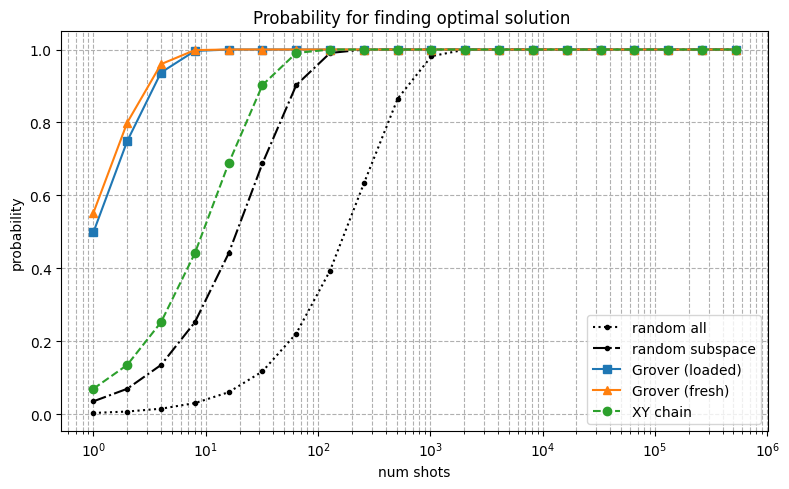

In [6]:
grover_hist = grover_result.qaoa_params.depths[maxdepth].histogram
n_qubits = grover_result.qaoa_params.N_qubits

fig = plt.figure(figsize=(8, 5))

plotHitProbabilities_fromHist(
    grover_hist, opt_sol,
    hamming_weight=hamming_weight,
    label="Grover (loaded)", style="s-", fig=fig,
    title="Probability of finding optimal solution",
)

plotHitProbabilities(
    qaoa_grover, opt_sol,
    label="Grover (fresh)", style="^-", fig=fig,
    plot_random=False,
)

plotHitProbabilities(
    qaoa_xy, opt_sol,
    label="XY chain", style="o--", fig=fig,
    plot_random=False,
)

plt.tight_layout()

## Compare optimal hit ratios across depths

We compare the probability of finding the optimal solution at each depth for all
three results: loaded Grover, fresh Grover, and XY mixer.

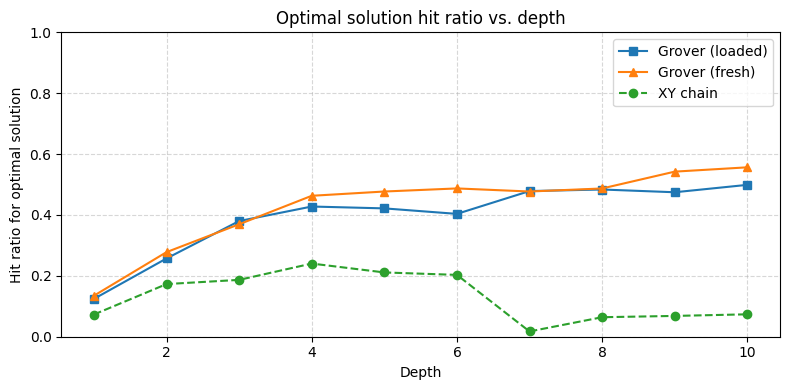

In [10]:
depths = sorted(grover_result.qaoa_params.depths.keys())
hist_shots = 2**13

grover_loaded_hit_rates = []
for d in depths:
    hist = grover_result.qaoa_params.depths[d].histogram
    total = sum(hist.values())
    grover_loaded_hit_rates.append(hist.get(opt_sol, 0) / total)

grover_fresh_hit_rates = []
for d in depths:
    hist = qaoa_grover.hist(qaoa_grover.optimization_results[d].get_best_angles(), hist_shots)
    grover_fresh_hit_rates.append(hist.get(opt_sol, 0) / hist_shots)

xy_hit_rates = []
for d in depths:
    hist = qaoa_xy.hist(qaoa_xy.optimization_results[d].get_best_angles(), hist_shots)
    xy_hit_rates.append(hist.get(opt_sol, 0) / hist_shots)

plt.figure(figsize=(8, 4))
plt.plot(depths, grover_loaded_hit_rates, "s-", label="Grover (loaded)")
plt.plot(depths, grover_fresh_hit_rates, "^-", label="Grover (fresh)")
plt.plot(depths, xy_hit_rates, "o--", label="XY chain")
plt.xlabel("Depth")
plt.ylim([0, 1])
plt.ylabel("Hit ratio for optimal solution")
plt.title("Optimal solution hit ratio vs. depth")
plt.legend()
plt.grid(True, ls="--", alpha=0.5)
plt.tight_layout()

## Compare feasible hit ratios across depths

We compare the probability of finding any feasible solution at each depth for
all three results.

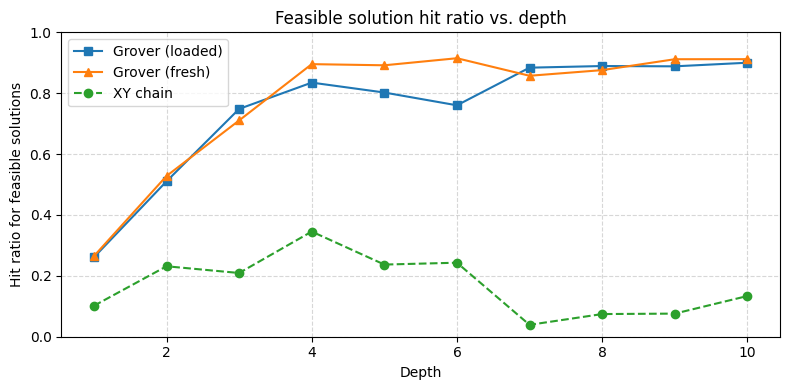

In [11]:
grover_loaded_feasible_rates = []
for d in depths:
    hist = grover_result.qaoa_params.depths[d].histogram
    total = sum(hist.values())
    feasible_hits = sum(c for bs, c in hist.items() if ec_problem.isFeasible(bs))
    grover_loaded_feasible_rates.append(feasible_hits / total)

grover_fresh_feasible_rates = []
for d in depths:
    hist = qaoa_grover.hist(qaoa_grover.optimization_results[d].get_best_angles(), hist_shots)
    feasible_hits = sum(c for bs, c in hist.items() if qaoa_grover.problem.isFeasible(bs))
    grover_fresh_feasible_rates.append(feasible_hits / hist_shots)

xy_feasible_rates = []
for d in depths:
    hist = qaoa_xy.hist(qaoa_xy.optimization_results[d].get_best_angles(), hist_shots)
    feasible_hits = sum(c for bs, c in hist.items() if qaoa_xy.problem.isFeasible(bs))
    xy_feasible_rates.append(feasible_hits / hist_shots)

plt.figure(figsize=(8, 4))
plt.plot(depths, grover_loaded_feasible_rates, "s-", label="Grover (loaded)")
plt.plot(depths, grover_fresh_feasible_rates, "^-", label="Grover (fresh)")
plt.plot(depths, xy_feasible_rates, "o--", label="XY chain")
plt.xlabel("Depth")
plt.ylabel("Hit ratio for feasible solutions")
plt.ylim([0, 1])
plt.title("Feasible solution hit ratio vs. depth")
plt.legend()
plt.grid(True, ls="--", alpha=0.5)
plt.tight_layout()

## Save XY-mixer result

In [9]:
xy_result = qio.QAOAResult.from_qaoa(
    qaoa_xy,
    solution=problem_data.solution,
    hist_shots=hist_shots,
)
xy_result.save(os.path.join("data", "exact_cover_path_problem_xy_result.json"))
print("XY-mixer result saved.")

XY-mixer result saved.
